# Leer los archivos

In [1]:
import os
import numpy as np
root_dir = r"../Spectra/FinalSamples"
dir_wln = os.path.join(root_dir, f"Level2/LVL2_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"Level2/LVL2_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")
dir_concentraciones = os.path.join(root_dir, f"concentraciones.txt")
concentraciones = np.genfromtxt(dir_concentraciones, skip_header=1) 

## Paquetes necesarios

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pymcr.mcr import McrAR
from scipy.optimize import nnls
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Dos concentraciones simultáneas

In [3]:
# ————————————— Datos de entrada —————————————
# wavelengths: array shape (N_wvls,)
# intensity_matrix: array shape (N_wvls, n_samples)
# conc: array shape (n_samples, 2)  columns = [Na, Mg]

D                = all_Spectra.T  # (n_samples, N_wvls)
conc             = concentraciones    # (n_samples,2)

In [4]:
# ————————————— Separar en train/test —————————————
indices = np.arange(D.shape[0])
train_idx, test_idx = train_test_split(indices, train_size=0.7, random_state=0)

D_train = D[train_idx, :]   # (n_train, N_wvls)
D_test  = D[test_idx,  :]   # (n_test,  N_wvls)
C_train = conc[train_idx, :]      # (n_train, 2)
C_test  = conc[test_idx, :]       # (n_test,  2)

In [5]:
# ————————————— Configurar MCR-ALS —————————————
mcrA = McrAR(
    c_regr='NNLS',
    st_regr='NNLS',
    max_iter=200,      
    tol_n_above_min = 10,
    tol_n_increase  = 10,
    tol_err_change  = 1e-6,
)

In [ ]:
# ————————————— Modelo A: inicializar con C_train —————————————
mcrA.fit(D_train, C=C_train, c_fix=[0,1])

# Extraer ST_estimada
ST_A = mcrA.ST_         # shape (2, N_wvls)
C_train_A = mcrA.C_     # should match (n_train, 2)

# Para test: resolver C_test_pred de ST_A · C^T ≈ D_test
# D ≈ ST^T · C^T  ⇒  D_test^T (n_test, N) = C_test_pred (n_test,2) · ST_A  (2,N)
# We solve each sample i: ST_A^T x = D_test[:,i] via NNLS
C_test_A = np.zeros((D_test.shape[0], 2))
for i in range(D_test.shape[0]):
    b = D_test[i, :]               # espectro i-ésimo, length=N_wvls
    C_test_A[i], _ = nnls(ST_A.T, b)

Change in err below tol_err_change (3.1522e-10). Exiting.


In [7]:
# ————————————— Evaluar errores —————————————
def compute_metrics(C_true, C_pred):
    metrics = {}
    for j, elem in enumerate(['Na','Mg']):
        y_true = C_true[:, j]
        y_pred = C_pred[:, j]
        metrics[f"{elem}_R2"]   = r2_score(y_true, y_pred)
        metrics[f"{elem}_RMSE"] = np.sqrt(mean_squared_error(y_true, y_pred))
    return metrics

metrics_A = compute_metrics(C_test, C_test_A)

print("=== Modelo A (C_init) sobre TEST ===")
print(metrics_A)

=== Modelo A (C_init) sobre TEST ===
{'Na_R2': 0.7237614086600732, 'Na_RMSE': 14.95572593349174, 'Mg_R2': 0.505637161690075, 'Mg_RMSE': 20.007288342721775}


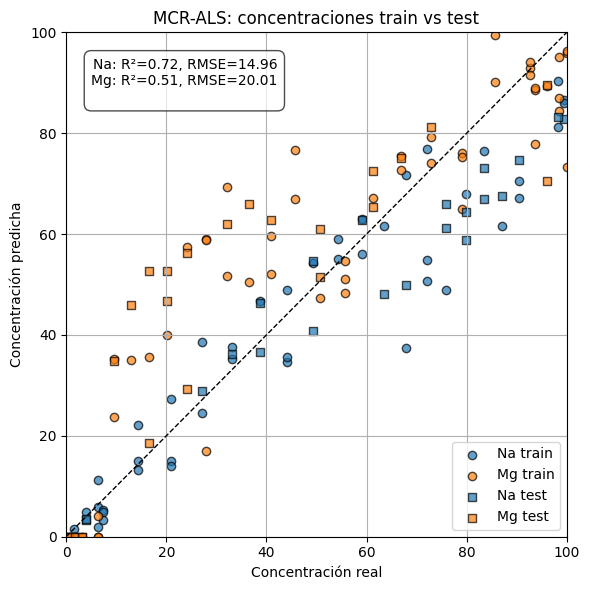

In [8]:
# Datos de Modelo A
# C_train_A: shape (n_train,2), C_test_A: shape (n_test,2)
# C_train, C_test: concentraciones reales

fig, ax = plt.subplots(figsize=(6,6))

elements = ['Na','Mg']
markers = {'train':'o', 'test':'s'}
colors  = {'Na':'C0', 'Mg':'C1'}
# Prepara el texto a mostrar
text_str = ""
for elem in elements:
    r2   = metrics_A[f"{elem}_R2"]
    rmse = metrics_A[f"{elem}_RMSE"]
    text_str += f"{elem}: R²={r2:.2f}, RMSE={rmse:.2f}\n"

ax.text(
    0.05, 0.95, text_str,
    transform=ax.transAxes,
    va='top', ha='left',ma = 'right',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)
# puntos de entrenamiento
for j, elem in enumerate(elements):
    ax.scatter(
        C_train[:, j],           # real
        C_train_A[:, j],         # predicho
        marker=markers['train'],
        color=colors[elem],
        edgecolor='k',
        label=f"{elem} train",
        alpha=0.7
    )

# puntos de test
for j, elem in enumerate(elements):
    ax.scatter(
        C_test[:, j],
        C_test_A[:, j],
        marker=markers['test'],
        color=colors[elem],
        edgecolor='k',
        label=f"{elem} test",
        alpha=0.7
    )

# línea de identidad
mn = 0
mx = 100
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)

ax.set_xlabel("Concentración real")
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.set_ylabel("Concentración predicha")
ax.set_title("MCR-ALS: concentraciones train vs test")
ax.legend(loc='lower right')
ax.grid(True)

plt.tight_layout()
plt.show()

# Probamos con el PCA antes del método

In [5]:
# ————————————— Datos de entrada —————————————
# wavelengths: array shape (N_wvls,)
# intensity_matrix: array shape (N_wvls, n_samples)
# conc: array shape (n_samples, 2)  columns = [Na, Mg]

D                = all_Spectra.T  # (n_samples, N_wvls)
conc             = concentraciones    # (n_samples,2)
# ————————————— Separar en train/test —————————————
indices = np.arange(D.shape[0])
train_idx, test_idx = train_test_split(indices, train_size=0.7, random_state=0)

D_train = D[train_idx, :]   # (n_train, N_wvls)
D_test  = D[test_idx,  :]   # (n_test,  N_wvls)
C_train = conc[train_idx, :]      # (n_train, 2)
C_test  = conc[test_idx, :]       # (n_test,  2)

In [6]:
from sklearn.decomposition import PCA
# ————————————— Reducir dimensionalidad con PCA —————————————
# D debe tener shape (n_samples, n_frequencies)
# Aquí lo proyectamos a n_components=10
# 1) PCA sin whitening y con suficientes PCs
pca = PCA(n_components=20, whiten=False, random_state=0)
pca.fit(D_train)
D_train_pca = pca.transform(D_train)    # (n_train, 20)
D_test_pca  = pca.transform(D_test)     # (n_test, 20)

# 2) Inicial guess de ST en PCA space
#    C_train es (n_train,2)
ST_init_pca = np.linalg.pinv(C_train) @ D_train_pca   # (2, 20)

In [12]:
# ————————————— Configurar MCR-ALS —————————————
mcrPCA = McrAR(
    c_regr='NNLS',
    st_regr='NNLS',
    max_iter=200,      
    tol_n_above_min = 10,
    tol_n_increase  = 10,
    tol_err_change  = 1e-6,
)
# ————————————— Modelo A: inicializar con C_train —————————————
# 4) Ajusto fijando C_train
mcrPCA.fit(D_train_pca, C=C_train, c_fix=[0,1], c_first=True)
# Extraer ST_estimada
ST_pca = mcrPCA.ST_         # shape (2, N_wvls)
C_train_pca = mcrPCA.C_     # should match (n_train, 2)

C_test_pca = np.zeros((D_test_pca.shape[0], 2))
for i in range(D_test_pca.shape[0]):
    b = D_test_pca[i]     # (20,)
    C_test_pca[i], _ = nnls(ST_pca.T, b)

Change in err below tol_err_change (0.0000e+00). Exiting.


In [13]:
# 6) Métricas
r2 = r2_score(C_test[:,0], C_test_pca[:,0])
rmse = np.sqrt(mean_squared_error(C_test[:,0], C_test_pca[:,0]))
print("Na in PCA-space: R²=", r2, "RMSE=", rmse)

Na in PCA-space: R²= -2.32051899554628 RMSE= 51.852333686899264


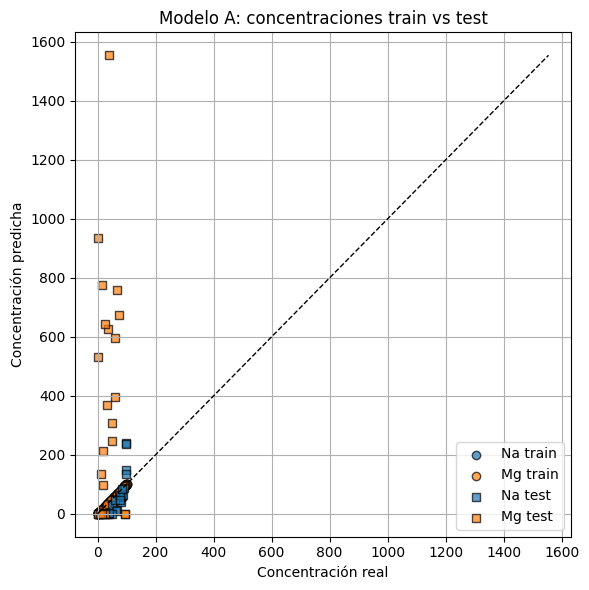

In [ ]:
# Datos de Modelo A
# C_train_pca: shape (n_train,2), C_test_pca: shape (n_test,2)
# C_train, C_test: concentraciones reales

fig, ax = plt.subplots(figsize=(6,6))

elements = ['Na','Mg']
markers = {'train':'o', 'test':'s'}
colors  = {'Na':'C0', 'Mg':'C1'}

# puntos de entrenamiento
for j, elem in enumerate(elements):
    ax.scatter(
        C_train[:, j],           # real
        C_train_pca[:, j],         # predicho
        marker=markers['train'],
        color=colors[elem],
        edgecolor='k',
        label=f"{elem} train",
        alpha=0.7
    )

# puntos de test
for j, elem in enumerate(elements):
    ax.scatter(
        C_test[:, j],
        C_test_pca[:, j],
        marker=markers['test'],
        color=colors[elem],
        edgecolor='k',
        label=f"{elem} test",
        alpha=0.7
    )

# línea de identidad
mn = min(C_train.min(), C_train_pca.min(), C_test.min(), C_test_pca.min())
mx = max(C_train.max(), C_train_pca.max(), C_test.max(), C_test_pca.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)

ax.set_xlabel("Concentración real")
ax.set_ylabel("Concentración predicha")
ax.set_title("Modelo PCA: concentraciones train vs test")
ax.legend(loc='best')
ax.grid(True)
plt.tight_layout()
plt.show()